# Machine Learning Pipeline

**Enterprise-Grade Recommendation System with Deep Learning**  
*Domain: E-Commerce / Retail*

---

The four mandated baselines, the collaborative-filtering improvements layered on top of them, and the content-based NLP recommender. These establish the bar that the deep model must clear to justify its serving cost.

## Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project modules importable from the notebooks folder.
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.append(os.path.join(BASE_DIR, "src"))
sys.path.append(os.path.join(BASE_DIR, "models"))

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Project root:", BASE_DIR)

Project root: E:\Recommendation_System_Final


## 1. Load artifacts

In [2]:
from data_loader import load_all
from preprocessing import load_pickle

users_df, items_df, interactions_df = load_all()
user_item_matrix = load_pickle('user_item_matrix.pkl')
normalized = load_pickle('normalized_user_item_matrix.pkl')

print('Rating matrix:', user_item_matrix.shape)

Rating matrix: (5766, 2264)


## 2. Baseline 1 - Popularity

The bar every other model must clear. Blends interaction count, average rating and conversion rate, so an item must be both widely seen *and* actually liked to reach the top.

In [3]:
from baseline_recommenders import build_popularity_model, recommend_popular, describe_items

popularity_df = build_popularity_model(interactions_df)
popularity_df.head(10)[['item_id', 'interaction_count', 'avg_rating',
                        'conversion_rate', 'popularity_score']]

,item_id,interaction_count,avg_rating,conversion_rate,popularity_score
0,1279,1377,3.997856,0.175744,0.775020
1,671,1312,3.884234,0.166921,0.742819
2,1629,1310,3.882609,0.166412,0.741893
3,985,1300,3.921769,0.157692,0.738865
4,656,1287,3.915332,0.174048,0.737026
5,457,1215,3.546798,0.134156,0.680773
6,1775,1186,3.701346,0.139123,0.680501
7,1383,1063,3.957300,0.174976,0.658334
8,1063,1070,3.910959,0.140187,0.651140
9,1367,1057,3.899604,0.140019,0.645701


## 3. Baselines 2 & 3 - User-based and Item-based CF

In [4]:
from baseline_recommenders import (create_user_similarity_matrix,
    create_item_similarity_matrix, recommend_user_based, recommend_item_based)

user_similarity = load_pickle('user_similarity.pkl')
item_similarity = load_pickle('item_similarity.pkl')

print('User-user similarity:', user_similarity.shape,
      '({:.0f} MB)'.format(user_similarity.memory_usage(deep=True).sum() / 1e6))
print('Item-item similarity:', item_similarity.shape,
      '({:.0f} MB)'.format(item_similarity.memory_usage(deep=True).sum() / 1e6))

User-user similarity: (5766, 5766) (133 MB)
Item-item similarity: (2264, 2264) (21 MB)


**The scalability warning.** The user-user matrix is O(users^2). At ~5,800 users it is manageable; at 100,000 users it would be 40 GB and simply cannot be held in memory. The item-item matrix is O(items^2) and grows far more slowly, because catalogues change much more slowly than user bases. This is why the architecture document recommends approximate nearest neighbours beyond roughly 50,000 users.

## 4. Baseline 4 - Matrix Factorisation (SVD)

The rating matrix is over 99% empty, so raw co-occurrence is far too thin. Compressing to 50 latent dimensions lets the model generalise across users who liked related-but-not-identical products.

  SVD explained variance (50 components): 33.09%


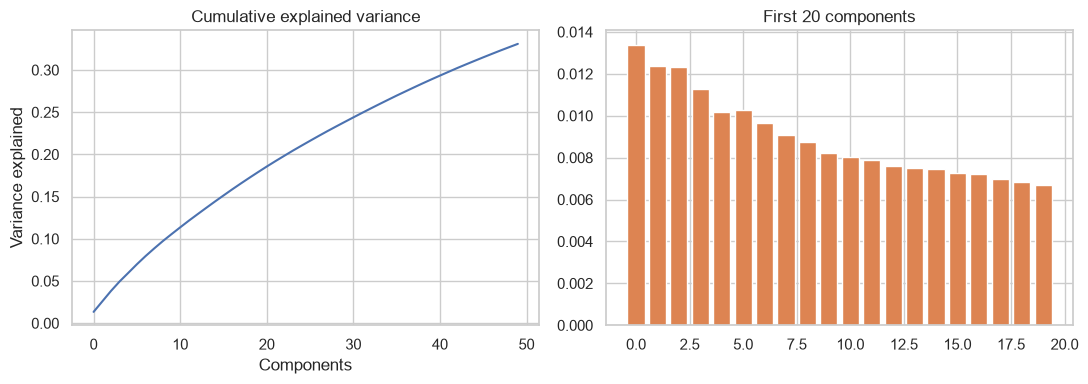

Total explained variance: 33.09%


In [5]:
from baseline_recommenders import create_svd_model

svd, user_factors, item_factors = create_svd_model(normalized, n_components=50)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(svd.explained_variance_ratio_), color='#4C72B0')
plt.title('Cumulative explained variance')
plt.xlabel('Components'); plt.ylabel('Variance explained')
plt.subplot(1, 2, 2)
plt.bar(range(20), svd.explained_variance_ratio_[:20], color='#DD8452')
plt.title('First 20 components')
plt.tight_layout(); plt.show()

print('Total explained variance: {:.2%}'.format(svd.explained_variance_ratio_.sum()))

Only about a third of the variance is captured. That is not a failure - on a 99% sparse matrix most of the remaining variance is noise in the unobserved cells. Pushing the component count higher fits that noise rather than signal.

## 5. Comparing all four baselines on one customer

In [6]:
from baseline_recommenders import recommend_svd

predicted = load_pickle('predicted_ratings.pkl')
sample_user = int(user_item_matrix.index[0])
profile = users_df[users_df['user_id'] == sample_user].iloc[0]

print('Customer #{} - {} who prefers {}\n'.format(
    sample_user, profile['user_segment'], profile['preferred_category']))

for label, recs in [
    ('Popularity', recommend_popular(sample_user, interactions_df, popularity_df, 5)),
    ('User-based CF', recommend_user_based(sample_user, user_item_matrix, user_similarity, 5)),
    ('Item-based CF', recommend_item_based(sample_user, user_item_matrix, item_similarity, 5)),
    ('SVD', recommend_svd(sample_user, user_item_matrix, predicted, 5)),
]:
    print(label + ':')
    print(describe_items(recs, items_df).to_string(index=False))
    print()

Customer #1 - Mainstream Buyer who prefers Grocery & Gourmet

Popularity:
item_id                             title               category      brand   price
   1279  Motorix Elite Car Accessorie 531             Automotive    Motorix 1394.90
    671        Coppernest Pro Storage 789         Home & Kitchen Coppernest 1376.24
   1629     Herbatone Heritage Makeup 418 Beauty & Personal Care  Herbatone 2723.61
    985  Denimworks Classic Sunglasse 784                Fashion Denimworks  573.38
    656 Brightloom Essential Lighting 470         Home & Kitchen Brightloom 3591.78

User-based CF:
item_id                              title          category      brand   price
    503 Orchardly Compact Organic Food 919 Grocery & Gourmet  Orchardly  141.94
   1279   Motorix Elite Car Accessorie 531        Automotive    Motorix 1394.90
   1498            Grainmill Pro Snack 142 Grocery & Gourmet  Grainmill  577.23
   1383 Torqline Prime Bike Accessorie 409        Automotive   Torqline 1598.64
    45

## 6. Content-based recommendation (NLP)

TF-IDF over the product description, tags, category and brand. Unlike every model above, this needs no interaction history at all - which is what makes it the answer to item cold start.

In [7]:
from content_based_nlp import (create_tfidf_features, recommend_similar_items,
                               get_cold_start_items, top_shared_terms)

items_with_text, vectorizer, tfidf_matrix = create_tfidf_features(items_df)
content_similarity = load_pickle('content_similarity.pkl')

print('TF-IDF matrix :', tfidf_matrix.shape)
print('Vocabulary    : {:,} terms'.format(len(vectorizer.get_feature_names_out())))
print('\nExample document:')
print(items_with_text['content_text'].iloc[0][:300])

TF-IDF matrix : (2500, 5000)
Vocabulary    : 5,000 terms

Example document:
Cassia Signature Activewear built for outdoor use. This Fashion product features casual and handcrafted construction. Part of the Cassia Activewear range, it is designed for frequent travellers who want reliable activewear performance. Key attributes: casual, handcrafted, leather, sustainable. Fashi


### Does the text representation actually work?

The test that matters: do items in the same subcategory score as more similar than items from unrelated categories?

In [8]:
sample_item = int(items_df['item_id'].iloc[0])
base = items_df[items_df['item_id'] == sample_item].iloc[0]
print('Source: {} ({} / {})\n'.format(base['title'], base['category'], base['subcategory']))

similar = recommend_similar_items(sample_item, items_with_text, content_similarity, 5)
print(similar[['title', 'category', 'subcategory', 'similarity_score']].to_string(index=False))

same_subcat = (similar['subcategory'] == base['subcategory']).mean()
print('\n{:.0%} of neighbours share the source subcategory'.format(same_subcat))

Source: Cassia Signature Activewear 583 (Fashion / Activewear)

                              title category subcategory  similarity_score
       Verdant Elite Activewear 511  Fashion  Activewear          0.471216
         Cassia Lite Activewear 633  Fashion  Activewear          0.446852
        Cassia Prime Activewear 844  Fashion  Activewear          0.429468
          Cassia Max Activewear 734  Fashion  Activewear          0.411531
Denimworks Essential Activewear 211  Fashion  Activewear          0.407699

100% of neighbours share the source subcategory


### Cold-start items

Collaborative filtering cannot score these at all - they have no interaction history by definition. The text representation carries the entire decision.

In [9]:
cold_items = get_cold_start_items(interactions_df, items_df)
print('Cold-start items: {:,}'.format(len(cold_items)))

cold_id = int(cold_items['item_id'].iloc[0])
cold_detail = items_df[items_df['item_id'] == cold_id].iloc[0]
print('\nCold item #{}: {} ({})'.format(cold_id, cold_detail['title'], cold_detail['category']))
print('Interactions: 0 - invisible to every collaborative model\n')

neighbours = recommend_similar_items(cold_id, items_with_text, content_similarity, 5)
print(neighbours[['title', 'category', 'similarity_score']].to_string(index=False))

print('\nShared terms driving the top match:')
print(' ', top_shared_terms(cold_id, int(neighbours.iloc[0]['item_id']),
                            items_df, vectorizer, tfidf_matrix))

Cold-start items: 255

Cold item #3: Claypeak Ultra Storage 103 (Home & Kitchen)
Interactions: 0 - invisible to every collaborative model

                            title       category  similarity_score
Claypeak Signature Dinnerware 446 Home & Kitchen          0.536520
      Claypeak Studio Storage 458 Home & Kitchen          0.501052
       Coppernest Pro Storage 570 Home & Kitchen          0.492920
        Claypeak Lite Storage 901 Home & Kitchen          0.474727
     Claypeak Classic Storage 544 Home & Kitchen          0.453155

Shared terms driving the top match:
  ['safe minimalist', 'claypeak', 'minimalist', 'safe', 'dishwasher']


## 7. Collaborative filtering improvements

Textbook CF fails in predictable ways. Each treatment below addresses a specific failure.

In [10]:
from collaborative_filtering import (build_popularity_lookup,
    rerank_with_popularity_balance, get_cold_start_users)

item_pop = load_pickle('item_popularity_features.pkl')
popularity_lookup = build_popularity_lookup(item_pop)

raw_scores = predicted.loc[sample_user]
reranked = rerank_with_popularity_balance(raw_scores, popularity_lookup)

before = raw_scores.nlargest(10).index
after = reranked.head(10).index

print('Popularity de-biasing, top 10:')
print('  mean exposure  : {:>7,.0f}  ->  {:>7,.0f}'.format(
    popularity_lookup.loc[before, 'interaction_count'].mean(),
    popularity_lookup.loc[after, 'interaction_count'].mean()))
print('  overlap with uncorrected ranking: {:.0%}'.format(
    len(set(before) & set(after)) / 10))

Popularity de-biasing, top 10:
  mean exposure  :     470  ->      458
  overlap with uncorrected ranking: 90%


**Two design decisions worth defending in detail.**

*Retrieve, then re-rank.* The diversity correction is applied only to the top 200 candidates by relevance, not across the whole catalogue. Applied catalogue-wide, a near-zero-exposure item the customer has no affinity for outranks a genuinely relevant one purely for being obscure - the system starts recommending obscurity for its own sake.

*Normalise before multiplying.* SVD runs on the mean-centred matrix, so its predictions are signed. Multiplying a negative score by a penalty in (0, 1) moves it *up* toward zero, silently inverting the correction for every negatively scored item. Min-max scaling first makes the multiplication mean what it says.

The first version of this used a `1 / (1 + log1p(count))` penalty, which spans a ~5x range - wider than the spread of the scores it multiplies. It dominated the ranking outright and returned only near-zero-exposure items, trading away all relevance for diversity. The current power form with alpha = 0.20 keeps the correction a nudge.

## Baseline summary

Measured on the held-out test period (see notebook 05 for the full benchmark):

| Model | NDCG@10 | Catalogue coverage |
|---|---|---|
| Item-based CF | 0.1044 | 22.2% |
| Popularity | 0.0645 | 1.3% |
| SVD | 0.0462 | 9.6% |
| Content (TF-IDF) | 0.0116 | 75.4% |

Item-based CF is the strongest classical model. Content-based is weakest on accuracy but has by far the best catalogue coverage - which is exactly why it earns a place in the hybrid despite its standalone score.